# RF-22 · Predicción de Gastos con Machine Learning
**Módulo:** Predicción IA  
**Prioridad:** 🔴 Must Have  
**Relacionado con:** HU-09, CU-05, RF-23

---

Este notebook predice los gastos mensuales futuros por categoría usando modelos ML
entrenados con el historial de transacciones del usuario.

**Precondición:** Historial de al menos 3 meses de transacciones.

**Salidas:**
- Gasto estimado total para el próximo mes
- Predicción por categoría con rango de confianza (min–max)
- Gráfico predicción vs histórico
- Detección de tendencias
- Explicación del cálculo en lenguaje simple


## 📦 Dependencias

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, date
from collections import defaultdict
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("✅ Dependencias cargadas.")


✅ Dependencias cargadas.


## 📥 Parámetros de Entrada
Celda taggeada con `parameters` para inyección via papermill desde la app.

El historial necesita **mínimo 3 meses** de transacciones para entrenar el modelo.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS DE ENTRADA — sustituir por datos reales desde la app
# ─────────────────────────────────────────────────────────────────────────────

# Historial de transacciones (solo gastos; los ingresos no son relevantes aquí)
transacciones = [
    # ── Noviembre 2024 ────────────────────────────────────────────────────────
    {"fecha": "2024-11-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-11-03", "monto": 95.00,  "categoria": "alimentacion"},
    {"fecha": "2024-11-07", "monto": 210.00, "categoria": "alimentacion"},
    {"fecha": "2024-11-10", "monto": 78.00,  "categoria": "transporte"},
    {"fecha": "2024-11-14", "monto": 45.00,  "categoria": "salud"},
    {"fecha": "2024-11-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-11-18", "monto": 130.00, "categoria": "ocio"},
    {"fecha": "2024-11-22", "monto": 55.00,  "categoria": "ropa"},
    {"fecha": "2024-11-28", "monto": 30.00,  "categoria": "otros"},
    # ── Diciembre 2024 ────────────────────────────────────────────────────────
    {"fecha": "2024-12-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2024-12-04", "monto": 115.00, "categoria": "alimentacion"},
    {"fecha": "2024-12-09", "monto": 230.00, "categoria": "alimentacion"},
    {"fecha": "2024-12-12", "monto": 88.00,  "categoria": "transporte"},
    {"fecha": "2024-12-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2024-12-19", "monto": 290.00, "categoria": "ocio"},       # Navidad
    {"fecha": "2024-12-22", "monto": 180.00, "categoria": "ropa"},       # Navidad
    {"fecha": "2024-12-26", "monto": 70.00,  "categoria": "salud"},
    {"fecha": "2024-12-29", "monto": 50.00,  "categoria": "otros"},
    # ── Enero 2025 ────────────────────────────────────────────────────────────
    {"fecha": "2025-01-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2025-01-05", "monto": 100.00, "categoria": "alimentacion"},
    {"fecha": "2025-01-09", "monto": 195.00, "categoria": "alimentacion"},
    {"fecha": "2025-01-11", "monto": 82.00,  "categoria": "transporte"},
    {"fecha": "2025-01-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2025-01-18", "monto": 110.00, "categoria": "ocio"},
    {"fecha": "2025-01-21", "monto": 40.00,  "categoria": "salud"},
    {"fecha": "2025-01-25", "monto": 35.00,  "categoria": "ropa"},
    {"fecha": "2025-01-28", "monto": 25.00,  "categoria": "otros"},
    # ── Febrero 2025 ──────────────────────────────────────────────────────────
    {"fecha": "2025-02-01", "monto": 750.00, "categoria": "vivienda"},
    {"fecha": "2025-02-04", "monto": 108.00, "categoria": "alimentacion"},
    {"fecha": "2025-02-08", "monto": 205.00, "categoria": "alimentacion"},
    {"fecha": "2025-02-12", "monto": 75.00,  "categoria": "transporte"},
    {"fecha": "2025-02-14", "monto": 85.00,  "categoria": "ocio"},       # San Valentín
    {"fecha": "2025-02-15", "monto": 60.00,  "categoria": "suscripciones"},
    {"fecha": "2025-02-20", "monto": 55.00,  "categoria": "salud"},
    {"fecha": "2025-02-22", "monto": 30.00,  "categoria": "ropa"},
    {"fecha": "2025-02-26", "monto": 20.00,  "categoria": "otros"},
]

# Fecha para la cual predecir (próximo mes respecto al último dato)
fecha_prediccion = "2025-03"   # YYYY-MM

# Umbral de precisión requerido (criterio de aceptación: >70%)
PRECISION_MINIMA = 0.70


## ⚙️ 1. Preparación de Datos

In [3]:
def agrupar_por_mes_categoria(transacciones: list) -> dict:
    """
    Agrupa gastos por mes y categoría.
    Devuelve: {"YYYY-MM": {"categoria": total, ...}, ...} ordenado cronológicamente.
    """
    meses = defaultdict(lambda: defaultdict(float))
    for t in transacciones:
        clave = t["fecha"][:7]
        meses[clave][t["categoria"]] += t["monto"]
    return dict(sorted(meses.items()))


def construir_series_temporales(meses_data: dict) -> dict:
    """
    Construye una serie temporal por categoría con índice numérico de mes.
    Rellena con 0 los meses sin gasto en esa categoría.
    """
    meses_list  = sorted(meses_data.keys())
    categorias  = sorted({cat for m in meses_data.values() for cat in m})
    series = {}
    for cat in categorias:
        series[cat] = [meses_data[m].get(cat, 0.0) for m in meses_list]
    # Total mensual
    series["__total__"] = [sum(meses_data[m].values()) for m in meses_list]
    return series, meses_list, categorias


meses_data   = agrupar_por_mes_categoria(transacciones)
series, meses_list, categorias = construir_series_temporales(meses_data)

n_meses = len(meses_list)
print(f"Meses disponibles ({n_meses}): {meses_list}")
print(f"Categorías detectadas: {categorias}")
print()
print("Gasto mensual por categoría (€):")
print(f"{'Categoría':<20}", end="")
for m in meses_list:
    print(f"{m:>12}", end="")
print()
print("─" * (20 + 12 * n_meses))
for cat in categorias:
    print(f"{cat:<20}", end="")
    for v in series[cat]:
        print(f"{v:>12.2f}", end="")
    print()
print("─" * (20 + 12 * n_meses))
print(f"{'TOTAL':<20}", end="")
for v in series["__total__"]:
    print(f"{v:>12.2f}", end="")
print()


Meses disponibles (4): ['2024-11', '2024-12', '2025-01', '2025-02']
Categorías detectadas: ['alimentacion', 'ocio', 'otros', 'ropa', 'salud', 'suscripciones', 'transporte', 'vivienda']

Gasto mensual por categoría (€):
Categoría                2024-11     2024-12     2025-01     2025-02
────────────────────────────────────────────────────────────────────
alimentacion              305.00      345.00      295.00      313.00
ocio                      130.00      290.00      110.00       85.00
otros                      30.00       50.00       25.00       20.00
ropa                       55.00      180.00       35.00       30.00
salud                      45.00       70.00       40.00       55.00
suscripciones              60.00       60.00       60.00       60.00
transporte                 78.00       88.00       82.00       75.00
vivienda                  750.00      750.00      750.00      750.00
────────────────────────────────────────────────────────────────────
TOTAL                 

## 🛠️ 2. Feature Engineering
Construimos features temporales para que el modelo pueda aprender patrones de estacionalidad y tendencia.


In [4]:
def construir_features(serie: list, ventana: int = 2) -> tuple:
    """
    Para una serie temporal [v0, v1, v2, ...] construye:
      X: matriz de features (lags, media móvil, índice temporal, mes del año)
      y: vector target (valor siguiente)
    """
    X, y = [], []
    for i in range(ventana, len(serie)):
        lags      = serie[i - ventana: i]                       # valores anteriores
        media_mov = np.mean(lags)                               # media de la ventana
        tendencia = lags[-1] - lags[0] if ventana > 1 else 0.0 # pendiente simple
        idx_mes   = i                                           # índice ordinal
        # Mes del calendario (para estacionalidad) — extraído de meses_list
        mes_cal   = int(meses_list[i].split("-")[1])

        fila = list(lags) + [media_mov, tendencia, idx_mes, mes_cal]
        X.append(fila)
        y.append(serie[i])
    return np.array(X, dtype=float), np.array(y, dtype=float)


# Nombres de features para explicabilidad
VENTANA = 2
feat_names_base = (
    [f"lag_{i+1}" for i in range(VENTANA)] +
    ["media_movil", "tendencia", "idx_mes", "mes_calendario"]
)

# Verificar que hay suficientes datos
assert n_meses >= 3, f"Se necesitan al menos 3 meses. Hay {n_meses}."
print(f"✅ Feature engineering con ventana={VENTANA}. Features: {feat_names_base}")
print(f"   Muestras disponibles para entrenamiento: {n_meses - VENTANA} por categoría")


✅ Feature engineering con ventana=2. Features: ['lag_1', 'lag_2', 'media_movil', 'tendencia', 'idx_mes', 'mes_calendario']
   Muestras disponibles para entrenamiento: 2 por categoría


## 🤖 3. Entrenamiento de Modelos por Categoría
Se entrena un modelo independiente por categoría + uno para el total.
Con pocos datos (<6 meses) usamos **Ridge Regression** (más estable).
Con más datos se añade **Gradient Boosting** y se elige el mejor por CV.


In [5]:
def seleccionar_modelo(n_muestras: int):
    """Elige el modelo según la cantidad de datos disponibles."""
    if n_muestras <= 4:
        return Ridge(alpha=1.0), "Ridge"
    elif n_muestras <= 8:
        return RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42), "RandomForest"
    else:
        return GradientBoostingRegressor(n_estimators=100, max_depth=2, random_state=42), "GradientBoosting"


def entrenar_y_evaluar(serie: list, nombre: str, ventana: int = 2) -> dict:
    """
    Entrena el modelo, evalúa con leave-one-out (dado el poco volumen de datos)
    y devuelve la predicción para el siguiente mes con intervalo de confianza.
    """
    X, y = construir_features(serie, ventana)
    if len(X) == 0:
        return {"error": "Datos insuficientes"}

    modelo, nombre_modelo = seleccionar_modelo(len(X))

    # ── Evaluación: Leave-One-Out sobre las últimas muestras ─────────────────
    maes, r2s = [], []
    for i in range(1, min(len(X), 4)):  # máx 3 splits
        X_tr, X_te = X[:-i], X[-i:]
        y_tr, y_te = y[:-i], y[-i:]
        if len(X_tr) == 0:
            continue
        modelo.fit(X_tr, y_tr)
        pred = modelo.predict(X_te)
        maes.append(mean_absolute_error(y_te, pred))
        if len(y_te) > 1 and y_te.std() > 0:
            r2s.append(r2_score(y_te, pred))

    # Entrenar con todos los datos para la predicción final
    modelo.fit(X, y)

    # ── Features del próximo mes ──────────────────────────────────────────────
    lags_next  = serie[-ventana:]
    media_next = np.mean(lags_next)
    tend_next  = lags_next[-1] - lags_next[0] if ventana > 1 else 0.0
    idx_next   = len(serie)
    # Mes siguiente en el calendario
    ultimo_mes = int(meses_list[-1].split("-")[1])
    mes_next   = (ultimo_mes % 12) + 1

    X_next = np.array([list(lags_next) + [media_next, tend_next, idx_next, mes_next]])
    pred_central = float(modelo.predict(X_next)[0])
    pred_central = max(0.0, pred_central)  # no puede ser negativo

    # ── Intervalo de confianza basado en MAE histórico ───────────────────────
    mae_medio = np.mean(maes) if maes else abs(pred_central * 0.15)
    pred_min  = max(0.0, round(pred_central - mae_medio * 1.5, 2))
    pred_max  = round(pred_central + mae_medio * 1.5, 2)

    # ── Tendencia ─────────────────────────────────────────────────────────────
    if len(serie) >= 2:
        diff = serie[-1] - serie[-2]
        if diff > serie[-1] * 0.05:
            tendencia = "📈 al alza"
        elif diff < -serie[-1] * 0.05:
            tendencia = "📉 a la baja"
        else:
            tendencia = "➡️ estable"
    else:
        tendencia = "➡️ estable"

    precision = 1 - (mae_medio / (np.mean(y) + 1e-6))
    precision = round(float(np.clip(precision, 0, 1)), 3)

    return {
        "categoria":      nombre,
        "modelo":         nombre_modelo,
        "prediccion":     round(pred_central, 2),
        "pred_min":       pred_min,
        "pred_max":       pred_max,
        "tendencia":      tendencia,
        "precision":      precision,
        "mae":            round(mae_medio, 2),
        "historico":      serie,
        "cumple_umbral":  precision >= PRECISION_MINIMA,
    }


# ── Entrenar para cada categoría y el total ───────────────────────────────────
resultados = {}
print(f"{'Categoría':<22} {'Modelo':<18} {'Pred (€)':<12} {'Min–Max':<20} {'Tendencia':<16} {'Precisión'}")
print("─" * 100)
for cat in categorias + ["__total__"]:
    res = entrenar_y_evaluar(series[cat], cat)
    resultados[cat] = res
    nombre_display = "TOTAL" if cat == "__total__" else cat
    umbral_icon    = "✅" if res["cumple_umbral"] else "⚠️"
    print(
        f"{nombre_display:<22} {res['modelo']:<18} {res['prediccion']:>8.2f}€   "
        f"[{res['pred_min']:.0f}–{res['pred_max']:.0f}]€{'':<6} "
        f"{res['tendencia']:<16} {res['precision']*100:.1f}% {umbral_icon}"
    )


Categoría              Modelo             Pred (€)     Min–Max              Tendencia        Precisión
────────────────────────────────────────────────────────────────────────────────────────────────────
alimentacion           Ridge                299.84€   [273–327]€       📈 al alza        94.1% ✅
ocio                   Ridge                 95.93€   [58–133]€       📉 a la baja      74.4% ✅
otros                  Ridge                 22.02€   [15–30]€       📉 a la baja      77.8% ✅
ropa                   Ridge                 32.48€   [25–40]€       📉 a la baja      84.6% ✅
salud                  Ridge                 42.98€   [20–65]€       📈 al alza        68.4% ⚠️
suscripciones          Ridge                 60.00€   [60–60]€       ➡️ estable       100.0% ✅
transporte             Ridge                 75.25€   [65–86]€       📉 a la baja      91.1% ✅
vivienda               Ridge                750.00€   [750–750]€       ➡️ estable       100.0% ✅
TOTAL                  Ridge        

## 📅 4. Comparación con Mes Anterior

In [6]:
ultimo_mes_data = meses_data[meses_list[-1]]

print(f"Comparación: {meses_list[-1]} (real) vs {fecha_prediccion} (predicción)\n")
print(f"{'Categoría':<22} {'Mes anterior':>14} {'Predicción':>12} {'Δ':>10} {'Tendencia'}")
print("─" * 75)

total_anterior  = 0
total_predicho  = 0
for cat in categorias:
    anterior  = ultimo_mes_data.get(cat, 0.0)
    predicho  = resultados[cat]["prediccion"]
    delta     = predicho - anterior
    delta_pct = (delta / anterior * 100) if anterior > 0 else 0
    icono     = "🔴" if delta > 0 else ("🟢" if delta < 0 else "⚪")
    total_anterior += anterior
    total_predicho += predicho
    print(f"{cat:<22} {anterior:>12.2f}€  {predicho:>10.2f}€  {icono} {delta:>+7.2f}€ ({delta_pct:+.1f}%)")

print("─" * 75)
delta_total = total_predicho - total_anterior
delta_pct_t = (delta_total / total_anterior * 100) if total_anterior > 0 else 0
print(f"{'TOTAL':<22} {total_anterior:>12.2f}€  {total_predicho:>10.2f}€     {delta_total:>+7.2f}€ ({delta_pct_t:+.1f}%)")


Comparación: 2025-02 (real) vs 2025-03 (predicción)

Categoría                Mes anterior   Predicción          Δ Tendencia
───────────────────────────────────────────────────────────────────────────
alimentacion                 313.00€      299.84€  🟢  -13.16€ (-4.2%)
ocio                          85.00€       95.93€  🔴  +10.93€ (+12.9%)
otros                         20.00€       22.02€  🔴   +2.02€ (+10.1%)
ropa                          30.00€       32.48€  🔴   +2.48€ (+8.3%)
salud                         55.00€       42.98€  🟢  -12.02€ (-21.9%)
suscripciones                 60.00€       60.00€  ⚪   +0.00€ (+0.0%)
transporte                    75.00€       75.25€  🔴   +0.25€ (+0.3%)
vivienda                     750.00€      750.00€  ⚪   +0.00€ (+0.0%)
───────────────────────────────────────────────────────────────────────────
TOTAL                       1388.00€     1378.50€       -9.50€ (-0.7%)


## 📊 5. Gráfico Predicción vs Histórico

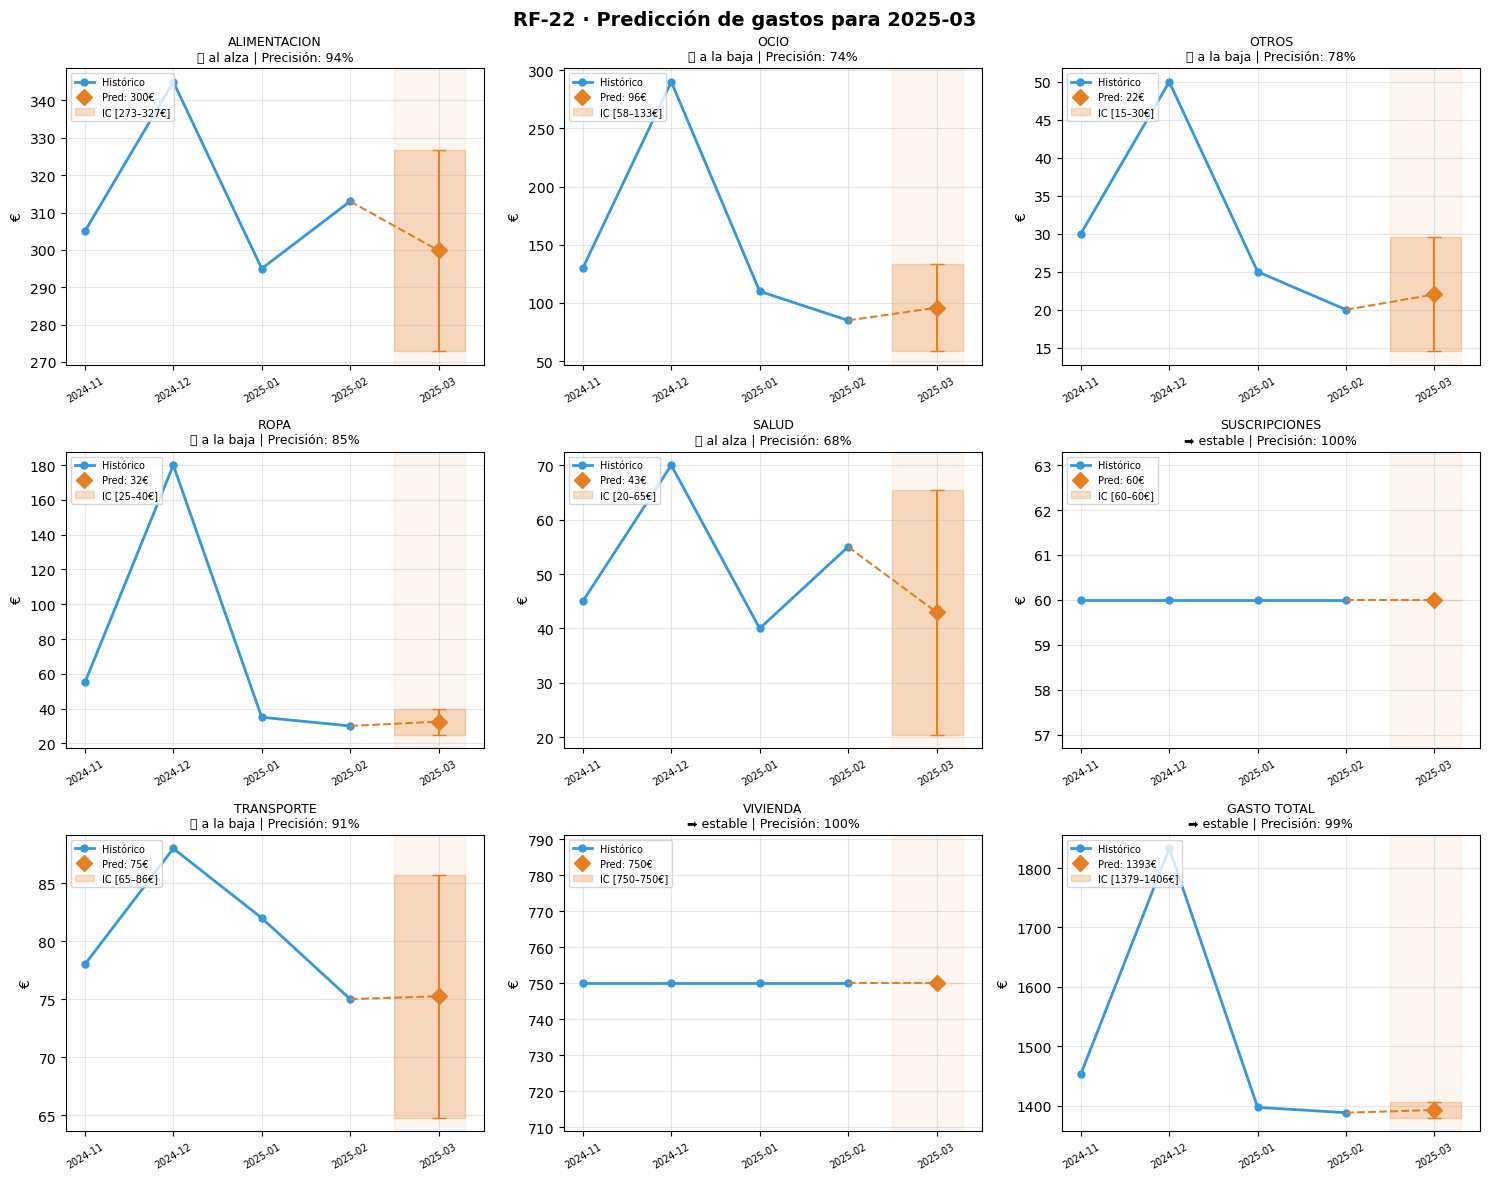

In [11]:
# Determinar layout según número de categorías
n_cats  = len(categorias)
n_cols  = 3
n_rows  = (n_cats + n_cols) // n_cols  # +n_cols para incluir el total

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle(f"RF-22 · Predicción de gastos para {fecha_prediccion}", fontsize=14, fontweight="bold")
axes_flat = axes.flatten() if n_rows > 1 else list(axes)

etiquetas_x = meses_list + [fecha_prediccion]

for idx, cat in enumerate(categorias + ["__total__"]):
    ax    = axes_flat[idx]
    res   = resultados[cat]
    hist  = res["historico"]
    pred  = res["prediccion"]
    pmin  = res["pred_min"]
    pmax  = res["pred_max"]
    titulo = "GASTO TOTAL" if cat == "__total__" else cat.upper()

    # Histórico
    x_hist = list(range(len(hist)))
    ax.plot(x_hist, hist, "o-", color="#3498db", linewidth=2, markersize=5, label="Histórico")

    # Predicción
    x_pred = len(hist)
    ax.plot([x_pred - 1, x_pred], [hist[-1], pred], "--", color="#e67e22", linewidth=1.5)
    ax.plot(x_pred, pred, "D", color="#e67e22", markersize=8, zorder=5, label=f"Pred: {pred:.0f}€")

    # Intervalo de confianza
    ax.fill_between([x_pred - 0.5, x_pred + 0.3], pmin, pmax,
                    alpha=0.25, color="#e67e22", label=f"IC [{pmin:.0f}–{pmax:.0f}€]")
    ax.errorbar(x_pred, pred, yerr=[[pred - pmin], [pmax - pred]],
                fmt="none", color="#e67e22", capsize=5, linewidth=1.5)

    ax.set_xticks(range(len(etiquetas_x)))
    ax.set_xticklabels(etiquetas_x, rotation=30, fontsize=7)
    ax.set_title(f"{titulo}\n{res['tendencia']} | Precisión: {res['precision']*100:.0f}%", fontsize=9)
    ax.set_ylabel("€")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.3)

    # Colorear fondo del mes predicho
    ax.axvspan(x_pred - 0.5, x_pred + 0.3, alpha=0.07, color="#e67e22")

# Ocultar ejes sobrantes
for i in range(len(categorias) + 1, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.savefig("rf22_prediccion_vs_historico.png", dpi=120, bbox_inches="tight")
plt.show()


## 📈 6. Detección de Tendencias por Categoría

In [12]:
def detectar_tendencia_detallada(serie: list, nombre: str) -> dict:
    """
    Analiza la tendencia de una serie con regresión lineal simple.
    Devuelve pendiente, dirección, magnitud y descripción.
    """
    if len(serie) < 2:
        return {"nombre": nombre, "direccion": "indeterminado", "pendiente": 0}

    x      = np.arange(len(serie), dtype=float)
    coeffs = np.polyfit(x, serie, 1)
    pend   = coeffs[0]
    media  = np.mean(serie)
    pct    = (pend / media * 100) if media > 0 else 0

    if pct > 5:
        direccion, icono = "al alza", "📈"
    elif pct < -5:
        direccion, icono = "a la baja", "📉"
    else:
        direccion, icono = "estable", "➡️"

    return {
        "nombre":    nombre,
        "direccion": direccion,
        "icono":     icono,
        "pendiente": round(float(pend), 2),
        "pct_mes":   round(float(pct), 1),
    }


print("Tendencias detectadas en el historial:\n")
tendencias = {}
for cat in categorias:
    t = detectar_tendencia_detallada(series[cat], cat)
    tendencias[cat] = t
    signo = "+" if t["pct_mes"] >= 0 else ""
    print(f"  {t['icono']} {cat:<20} {t['direccion']:<12}  {signo}{t['pct_mes']}% por mes  (Δ {signo}{t['pendiente']:.2f}€/mes)")

# Alerta categorías con crecimiento fuerte
alertas_tendencia = [t for t in tendencias.values() if t["pct_mes"] > 10]
if alertas_tendencia:
    print("\n⚠️  Categorías con crecimiento acelerado (>10%/mes):")
    for t in alertas_tendencia:
        print(f"   • {t['nombre']}: +{t['pct_mes']}%/mes — considera revisar estos gastos")


Tendencias detectadas en el historial:

  ➡️ alimentacion         estable       -0.8% por mes  (Δ -2.60€/mes)
  📉 ocio                 a la baja     -20.5% por mes  (Δ -31.50€/mes)
  📉 otros                a la baja     -17.6% por mes  (Δ -5.50€/mes)
  📉 ropa                 a la baja     -29.3% por mes  (Δ -22.00€/mes)
  ➡️ salud                estable       +-0.0% por mes  (Δ +-0.00€/mes)
  ➡️ suscripciones        estable       +0.0% por mes  (Δ +0.00€/mes)
  ➡️ transporte           estable       -1.9% por mes  (Δ -1.50€/mes)
  ➡️ vivienda             estable       +0.0% por mes  (Δ +0.00€/mes)


## ✅ 7. Evaluación de Precisión del Modelo
Criterio de aceptación: *«Precisión del modelo > 70% (evaluación continua)»*


In [13]:
print(f"Evaluación de precisión (umbral mínimo: {PRECISION_MINIMA*100:.0f}%)\n")
print(f"{'Categoría':<22} {'Precisión':>10} {'MAE':>10} {'Estado'}")
print("─" * 55)

precisions = []
for cat in categorias + ["__total__"]:
    res   = resultados[cat]
    p     = res["precision"]
    mae   = res["mae"]
    icon  = "✅" if res["cumple_umbral"] else "⚠️  BAJO UMBRAL"
    nombre = "TOTAL" if cat == "__total__" else cat
    print(f"{nombre:<22} {p*100:>9.1f}%  {mae:>8.2f}€  {icon}")
    precisions.append(p)

precision_global = np.mean(precisions)
print("─" * 55)
print(f"{'Precisión global promedio':<22} {precision_global*100:>9.1f}%")
print()
if precision_global >= PRECISION_MINIMA:
    print(f"✅ El modelo supera el umbral de {PRECISION_MINIMA*100:.0f}% de precisión global.")
else:
    print(f"⚠️  El modelo no alcanza el umbral de {PRECISION_MINIMA*100:.0f}%. Se recomienda:")
    print("   • Acumular más meses de historial")
    print("   • Revisar si hay transacciones atípicas en el historial")
    print("   • Considerar reentrenamiento tras el próximo mes real")


Evaluación de precisión (umbral mínimo: 70%)

Categoría               Precisión        MAE Estado
───────────────────────────────────────────────────────
alimentacion                94.1%     18.00€  ✅
ocio                        74.4%     25.00€  ✅
otros                       77.8%      5.00€  ✅
ropa                        84.6%      5.00€  ✅
salud                       68.4%     15.00€  ⚠️  BAJO UMBRAL
suscripciones              100.0%      0.00€  ✅
transporte                  91.1%      7.00€  ✅
vivienda                   100.0%      0.00€  ✅
TOTAL                       99.4%      9.00€  ✅
───────────────────────────────────────────────────────
Precisión global promedio      87.8%

✅ El modelo supera el umbral de 70% de precisión global.


## 💬 8. Explicación en Lenguaje Simple

In [14]:
def generar_explicacion(resultados, meses_list, fecha_prediccion, categorias):
    """Genera texto explicativo para mostrar al usuario en la app."""
    total_res = resultados["__total__"]
    lineas = [
        f"📅 Predicción para {fecha_prediccion} basada en {len(meses_list)} meses de historial:",
        "",
        f"  💰 Gasto total estimado: {total_res['prediccion']:.2f}€",
        f"     Rango posible: entre {total_res['pred_min']:.0f}€ y {total_res['pred_max']:.0f}€",
        f"     Tendencia general: {total_res['tendencia']}",
        "",
        "  Por categorías:",
    ]
    for cat in sorted(categorias, key=lambda c: resultados[c]["prediccion"], reverse=True):
        r = resultados[cat]
        lineas.append(
            f"    • {cat:<18} {r['prediccion']:>8.2f}€  "
            f"[{r['pred_min']:.0f}–{r['pred_max']:.0f}€]  {r['tendencia']}"
        )
    lineas += [
        "",
        "  ℹ️  Cómo se calculó:",
        f"     El sistema analizó tus últimos {len(meses_list)} meses de gastos,",
        "     aprendió los patrones de cada categoría y proyectó el siguiente mes.",
        "     El rango (mínimo–máximo) indica la variabilidad esperada.",
        f"     Precisión global del modelo: {np.mean([resultados[c]['precision'] for c in categorias])*100:.0f}%",
    ]
    return "\n".join(lineas)


explicacion = generar_explicacion(resultados, meses_list, fecha_prediccion, categorias)
print(explicacion)


📅 Predicción para 2025-03 basada en 4 meses de historial:

  💰 Gasto total estimado: 1392.53€
     Rango posible: entre 1379€ y 1406€
     Tendencia general: ➡️ estable

  Por categorías:
    • vivienda             750.00€  [750–750€]  ➡️ estable
    • alimentacion         299.84€  [273–327€]  📈 al alza
    • ocio                  95.93€  [58–133€]  📉 a la baja
    • transporte            75.25€  [65–86€]  📉 a la baja
    • suscripciones         60.00€  [60–60€]  ➡️ estable
    • salud                 42.98€  [20–65€]  📈 al alza
    • ropa                  32.48€  [25–40€]  📉 a la baja
    • otros                 22.02€  [15–30€]  📉 a la baja

  ℹ️  Cómo se calculó:
     El sistema analizó tus últimos 4 meses de gastos,
     aprendió los patrones de cada categoría y proyectó el siguiente mes.
     El rango (mínimo–máximo) indica la variabilidad esperada.
     Precisión global del modelo: 86%


## 📤 9. Salida Estructurada (JSON)
Payload que devolverá el endpoint FastAPI.

In [16]:
salida = {
    "fecha_prediccion":  fecha_prediccion,
    "meses_analizados":  len(meses_list),
    "precision_global":  round(float(np.mean([resultados[c]["precision"] for c in categorias])), 3),
    "cumple_umbral": bool(precision_global >= PRECISION_MINIMA),
    "total": {
        "prediccion":  resultados["__total__"]["prediccion"],
        "pred_min":    resultados["__total__"]["pred_min"],
        "pred_max":    resultados["__total__"]["pred_max"],
        "tendencia":   resultados["__total__"]["tendencia"],
    },
    "por_categoria": {
        cat: {
            "prediccion": resultados[cat]["prediccion"],
            "pred_min":   resultados[cat]["pred_min"],
            "pred_max":   resultados[cat]["pred_max"],
            "tendencia":  resultados[cat]["tendencia"],
            "precision":  resultados[cat]["precision"],
        }
        for cat in categorias
    },
    "comparacion_mes_anterior": {
        cat: {
            "anterior":   round(meses_data[meses_list[-1]].get(cat, 0.0), 2),
            "prediccion": resultados[cat]["prediccion"],
            "delta":      round(resultados[cat]["prediccion"] - meses_data[meses_list[-1]].get(cat, 0.0), 2),
        }
        for cat in categorias
    },
    "alertas_tendencia": [
        {"categoria": t["nombre"], "pct_mes": t["pct_mes"]}
        for t in tendencias.values() if t["pct_mes"] > 10
    ],
    "explicacion": explicacion,
}

print(json.dumps(salida, ensure_ascii=False, indent=2))


{
  "fecha_prediccion": "2025-03",
  "meses_analizados": 4,
  "precision_global": 0.863,
  "cumple_umbral": true,
  "total": {
    "prediccion": 1392.53,
    "pred_min": 1379.03,
    "pred_max": 1406.03,
    "tendencia": "➡️ estable"
  },
  "por_categoria": {
    "alimentacion": {
      "prediccion": 299.84,
      "pred_min": 272.84,
      "pred_max": 326.84,
      "tendencia": "📈 al alza",
      "precision": 0.941
    },
    "ocio": {
      "prediccion": 95.93,
      "pred_min": 58.43,
      "pred_max": 133.43,
      "tendencia": "📉 a la baja",
      "precision": 0.744
    },
    "otros": {
      "prediccion": 22.02,
      "pred_min": 14.52,
      "pred_max": 29.52,
      "tendencia": "📉 a la baja",
      "precision": 0.778
    },
    "ropa": {
      "prediccion": 32.48,
      "pred_min": 24.98,
      "pred_max": 39.98,
      "tendencia": "📉 a la baja",
      "precision": 0.846
    },
    "salud": {
      "prediccion": 42.98,
      "pred_min": 20.48,
      "pred_max": 65.48,
      "te